In [1]:
import numpy as np
import pandas as pd
import datetime
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

1. Aggregate the tornado data over the following states into a monthly count of tornadoes: Illinois

In [2]:
# import dataset
ds = pd.read_csv("1950-2021_actual_tornadoes.csv")
ds

,om,yr,mo,dy,date,time,tz,st,stf,stn,...,len,wid,ns,sn,sg,f1,f2,f3,f4,fc
0,192,1950,10,1,1950-10-01,21:00:00,3,OK,40,23,...,15.80,10,1,1,1,25,0,0,0,0
1,193,1950,10,9,1950-10-09,02:15:00,3,NC,37,9,...,2.00,880,1,1,1,47,0,0,0,0
2,195,1950,11,20,1950-11-20,02:20:00,3,KY,21,1,...,0.10,10,1,1,1,177,0,0,0,0
3,196,1950,11,20,1950-11-20,04:00:00,3,KY,21,2,...,0.10,10,1,1,1,209,0,0,0,0
4,197,1950,11,20,1950-11-20,07:30:00,3,MS,28,14,...,2.00,37,1,1,1,101,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67553,620523,2021,9,8,2021-09-08,15:32:00,3,PA,42,0,...,0.73,30,1,1,1,109,0,0,0,0
67554,620524,2021,9,8,2021-09-08,15:35:00,3,PA,42,0,...,1.45,30,1,1,1,109,0,0,0,0
67555,620525,2021,9,8,2021-09-08,19:08:00,3,FL,12,0,...,1.45,50,1,1,1,129,0,0,0,0
67556,620526,2021,9,9,2021-09-09,02:10:00,3,CT,9,0,...,0.75,75,1,1,1,13,0,0,0,0


In [3]:
# filtering for Illinois only
dsil = ds[ds["st"] == "IL"].copy()
dsil

,om,yr,mo,dy,date,time,tz,st,stf,stn,...,len,wid,ns,sn,sg,f1,f2,f3,f4,fc
6,198,1950,12,2,1950-12-02,15:00:00,3,IL,17,7,...,18.80,50,1,1,1,119,117,0,0,0
7,199,1950,12,2,1950-12-02,16:00:00,3,IL,17,8,...,18.00,200,1,1,1,119,5,0,0,0
9,201,1950,12,2,1950-12-02,17:30:00,3,IL,17,9,...,9.60,50,1,1,1,157,0,0,0,0
12,6,1950,1,25,1950-01-25,21:00:00,3,IL,17,3,...,0.10,100,1,1,1,91,0,0,0,0
15,2,1950,1,3,1950-01-03,11:55:00,3,IL,17,2,...,3.60,130,1,1,1,135,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67519,620382,2021,8,9,2021-08-09,17:26:00,3,IL,17,0,...,0.20,20,1,1,1,37,0,0,0,0
67520,620383,2021,8,9,2021-08-09,17:28:00,3,IL,17,0,...,3.90,400,1,1,1,89,0,0,0,0
67521,620384,2021,8,9,2021-08-09,17:38:00,3,IL,17,0,...,0.10,10,1,1,1,89,0,0,0,0
67522,620385,2021,8,9,2021-08-09,17:57:00,3,IL,17,0,...,3.00,525,1,1,1,11,0,0,0,0


In [4]:
# formatting date column into datetime 
dsil["date"] = pd.to_datetime(dsil["date"])

In [5]:
# creating year-month for then doing a groupby month next
dsil["year_month"] = dsil["date"].dt.to_period("M")

In [6]:
# performing groupby function based on number of tornado events 
monthly_counts = (dsil.groupby("year_month").size().reset_index(name="tornado_count"))

In [7]:
monthly_counts = monthly_counts.rename(columns={"year_month": "Date"})
monthly_counts["Date"] = monthly_counts["Date"].dt.to_timestamp()
monthly_counts

,Date,tornado_count
0,1950-01-01,2
1,1950-03-01,1
2,1950-06-01,1
3,1950-07-01,1
4,1950-12-01,3
...,...,...
440,2021-06-01,15
441,2021-07-01,8
442,2021-08-01,16
443,2021-10-01,10


2. Merge this monthly tornado dataset with the ENSO, PDO, NAO, and AO dataframe created in Module 4 Notebook 1.

In [8]:
# The following several code cells are fromo M4N1:

enso = pd.read_csv('https://www.atmos.illinois.edu/~snesbitt/soi.dat',sep=r'\s+',header=None,skiprows=4,skipfooter=0, engine='python')
pdo = pd.read_csv('https://www.ncei.noaa.gov/pub/data/cmb/ersst/v5/index/ersst.v5.pdo.dat',sep=r'\s+',header=None,skiprows=2, engine='python')
nao = pd.read_csv('https://www.cpc.ncep.noaa.gov/products/precip/CWlink/pna/norm.nao.monthly.b5001.current.ascii.table',sep=r'\s+',header=None,skiprows=1, engine='python')
ao = pd.read_csv('https://www.cpc.ncep.noaa.gov/products/precip/CWlink/daily_ao_index/monthly.ao.index.b50.current.ascii.table',sep=r'\s+',header=None,skiprows=1, engine='python')

In [9]:
enso_new=pd.DataFrame()
nao_new=pd.DataFrame()
pdo_new=pd.DataFrame()
ao_new=pd.DataFrame()

enso_new['Date'] = pd.date_range(start=datetime.datetime(enso[0].iloc[0],1,1),end=datetime.datetime(enso[0].iloc[-1],12,1),freq="MS")
nao_new['Date'] = pd.date_range(start=datetime.datetime(nao[0].iloc[0],1,1),end=datetime.datetime(nao[0].iloc[-1],12,1),freq="MS")
pdo_new['Date'] = pd.date_range(start=datetime.datetime(pdo[0].iloc[0],1,1),end=datetime.datetime(pdo[0].iloc[-1],12,1),freq="MS")
ao_new['Date'] = pd.date_range(start=datetime.datetime(ao[0].iloc[0],1,1),end=datetime.datetime(ao[0].iloc[-1],12,1),freq="MS")

enso_new = enso_new.set_index('Date')
nao_new = nao_new.set_index('Date')
pdo_new = pdo_new.set_index('Date')
ao_new = ao_new.set_index('Date')

enso_new['ENSO']=enso.loc[:,1:].stack(dropna=False).values
nao_new['NAO']=nao.loc[:,1:].stack(dropna=False).values
pdo_new['PDO']=pdo.loc[:,1:].stack(dropna=False).values
ao_new['AO']=ao.loc[:,1:].stack(dropna=False).values

/tmp/ipykernel_1183/1228193739.py:16: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  enso_new['ENSO']=enso.loc[:,1:].stack(dropna=False).values
/tmp/ipykernel_1183/1228193739.py:17: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  nao_new['NAO']=nao.loc[:,1:].stack(dropna=False).values
/tmp/ipykernel_1183/1228193739.py:18: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.

In [10]:
newdf_all = pd.merge(enso_new,pdo_new, left_index=True, right_index=True)
newdf_all.loc[newdf_all['PDO'] > 90.,'PDO'] = np.nan
newdf_all.loc[newdf_all['ENSO'] <= -9.9,'ENSO'] = np.nan
newdf_all = pd.merge(newdf_all,nao_new, left_index=True, right_index=True)
newdf_all.loc[newdf_all['NAO'] <= -99.9,'NAO'] = np.nan
newdf_all = pd.merge(newdf_all,ao_new, left_index=True, right_index=True)
newdf_all.loc[newdf_all['AO'] <= -99.9,'AO'] = np.nan
newdf_all

,ENSO,PDO,NAO,AO
Date,,,,
1951-01-01,1.5,-1.19,0.08,-0.085
1951-02-01,0.9,-1.52,0.70,-0.400
1951-03-01,-0.1,-1.72,-1.02,-1.934
1951-04-01,-0.3,-1.35,-0.22,-0.776
1951-05-01,-0.7,-1.29,-0.59,-0.863
...,...,...,...,...
2025-08-01,0.4,-3.20,0.26,0.036
2025-09-01,0.0,-2.33,-0.80,0.048
2025-10-01,NaN,-2.40,-0.96,0.064


In [11]:
# and now addressing the initial task of merging with the IL tornado dataset
# also making sure there is a month column for use later in the assignment

new = pd.merge(newdf_all,monthly_counts, on= "Date")
new["Month"] = new["Date"].dt.month
new

,Date,ENSO,PDO,NAO,AO,tornado_count,Month
0,1951-06-01,0.2,-1.77,-1.64,-0.918,2,6
1,1951-11-01,-0.8,-0.31,-0.39,-0.069,2,11
2,1951-12-01,-0.7,-1.45,1.32,1.987,1,12
3,1952-03-01,0.5,-1.67,-1.49,-1.859,2,3
4,1952-05-01,0.8,-2.07,-1.12,-0.774,1,5
...,...,...,...,...,...,...,...
435,2021-06-01,0.4,-1.82,0.77,0.845,15,6
436,2021-07-01,1.4,-2.00,0.03,0.630,8,7
437,2021-08-01,0.6,-0.95,-0.28,-0.209,16,8
438,2021-10-01,0.7,-3.13,-2.29,-0.146,10,10


3. Create a random forest regression model and use features that include the 4 climate indices to predict the monthly number of tornadoes. Create a scatter plot of the predicted and observed number of tornadoes over these states. Report the correlation coefficient and RMSE of your model.

In [12]:
# first establish the features matrix and target array
X_dsfeatures = new[['ENSO','PDO','NAO','AO','Month']]
X_dsfeatures.shape

(440, 5)

In [13]:
y_dstarget = new['tornado_count']
y_dstarget.shape

(440,)

In [14]:
# split into training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(X_dsfeatures, y_dstarget, random_state=0)

In [15]:
# create random forest regressor model
model = RandomForestRegressor(random_state=0)
model.fit(X_train, y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
# and now generate predictions using the model
y_pred = model.predict(X_test)

In [17]:
from sklearn.metrics import r2_score, mean_squared_error
test_r2 = r2_score(y_test, y_pred)
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
corr = np.corrcoef(y_test, y_pred)[0, 1]
print("Correlation Coefficient:", corr)
print("Testing Set R² Score:", test_r2)
print("Testing Set Root Mean Squared Error:", test_rmse)


Correlation Coefficient: 0.07298729000293591
Testing Set R² Score: -0.20711758732007546
Testing Set Root Mean Squared Error: 7.44995771800082


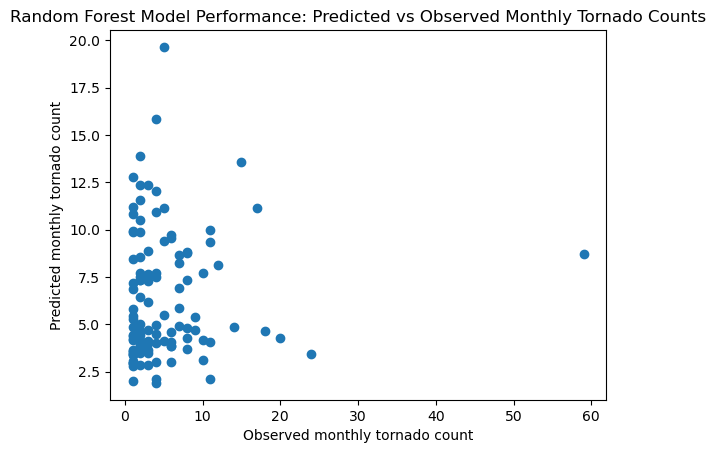

In [18]:
plt.scatter(y_test, y_pred)
plt.xlabel("Observed monthly tornado count")
plt.ylabel("Predicted monthly tornado count")
plt.title("Random Forest Model Performance: Predicted vs Observed Monthly Tornado Counts")
plt.show()

4. Create a one-hot encoding for the month of the year. Repeat the scatterplot and compare the RMSE and correlation coefficient values.

In [19]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder(sparse_output=False)    
month_encoded = enc.fit_transform(new[["Month"]])
month_encoded

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(440, 12))

In [20]:
month_cols = enc.get_feature_names_out(["Month"])
month_df = pd.DataFrame(month_encoded, columns=month_cols, index=new.index)
month_df

,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
435,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
436,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
437,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
438,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [21]:
X_final = pd.concat([X_dsfeatures, month_df], axis=1)
X_final = X_final.drop(columns=['Month'])
X_final

,ENSO,PDO,NAO,AO,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12
0,0.2,-1.77,-1.64,-0.918,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.8,-0.31,-0.39,-0.069,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,-0.7,-1.45,1.32,1.987,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.5,-1.67,-1.49,-1.859,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.8,-2.07,-1.12,-0.774,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
435,0.4,-1.82,0.77,0.845,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
436,1.4,-2.00,0.03,0.630,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
437,0.6,-0.95,-0.28,-0.209,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
438,0.7,-3.13,-2.29,-0.146,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [22]:
# split this new one-hot encoded set into training and testing datasets
X_trainOH, X_testOH, y_trainOH, y_testOH = train_test_split(X_final, y_dstarget, random_state=0)

In [23]:
# create random forest regressor model
modelOH = RandomForestRegressor(random_state=0)
modelOH.fit(X_trainOH, y_trainOH)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
# and now generate predictions using the model
y_predOH = modelOH.predict(X_testOH)

In [25]:
testOH_r2 = r2_score(y_testOH, y_predOH)
testOH_mse = mean_squared_error(y_testOH, y_predOH)
testOH_rmse = np.sqrt(testOH_mse)
corr = np.corrcoef(y_testOH, y_predOH)[0, 1]
print("Correlation Coefficient:", corr)
print("Testing Set R² Score:", testOH_r2)
print("Training Set Root Mean Squared Error:", testOH_rmse)


Correlation Coefficient: 0.12363516388521521
Testing Set R² Score: -0.1054757002861546
Training Set Root Mean Squared Error: 7.1294104690614954


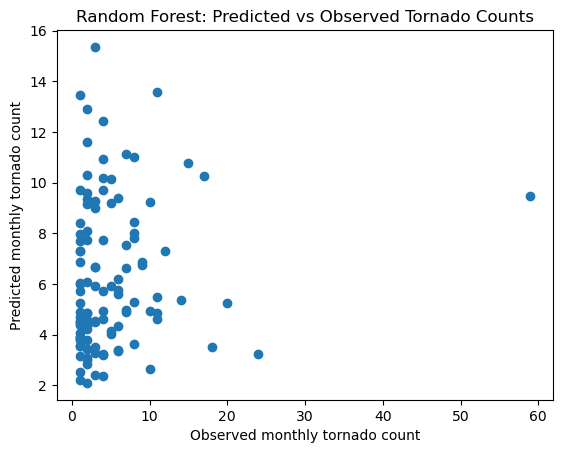

In [26]:
plt.scatter(y_testOH, y_predOH)
plt.xlabel("Observed monthly tornado count")
plt.ylabel("Predicted monthly tornado count")
plt.title("Random Forest: Predicted vs Observed Tornado Counts")
plt.show()

5. Perform a feature importance and multipass permutation analysis of your features.

In [27]:
# MDI feature importance
mdi_importances = pd.Series(
    modelOH.feature_importances_,  
    index=X_final.columns         
).sort_values(ascending=True)     

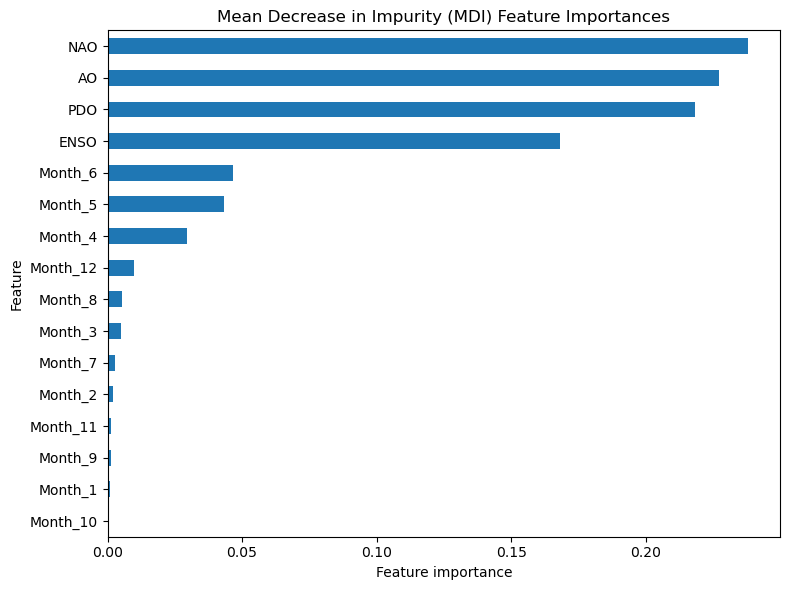

In [28]:
mdi_importances.plot(kind='barh', figsize=(8,6))
plt.title("Mean Decrease in Impurity (MDI) Feature Importances")
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Notes: MDI shows how much a feature contributes to reducing the error of a random forest model across all trees in the ensemble. Features that are used more often in splits and lead to a greater decrease in impurity are ranked as more important. There is a known limitation that values with high cardinality (with many unique values, like continuous values (i.e., climate indicators)) are favored because they have so many opportunities for splits, as opposed to the counts per month which have a few discrete values per feature.

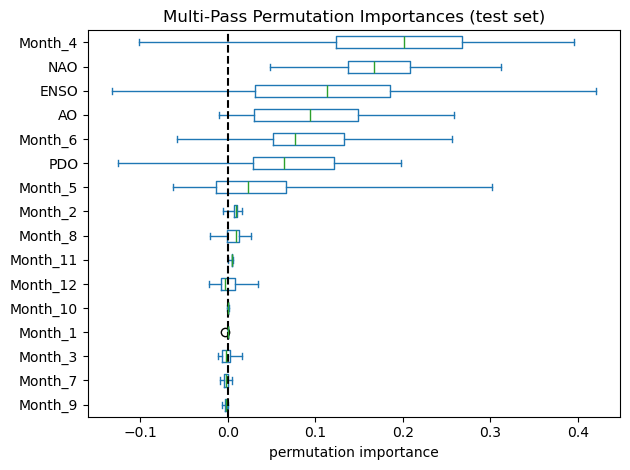

In [29]:
from sklearn.inspection import permutation_importance

result = permutation_importance(modelOH, X_testOH, y_testOH, n_repeats=50, random_state=42, n_jobs=2)

sorted_importances_idx = result.importances_mean.argsort()
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=X_final.columns[sorted_importances_idx],
)
ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Multi-Pass Permutation Importances (test set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("permutation importance")
ax.figure.tight_layout()

6. Create a SHAP Summary Plot showing feature importance and feature effects.

In [30]:
!pip install shap
import shap
shap.initjs()

In [31]:
explainer = shap.Explainer(modelOH, X_trainOH, feature_names=X_final.columns)
shap_values = explainer(X_testOH, check_additivity=False) 
shap_values

.values =
array([[-6.89718347e-01, -2.02858344e-01,  6.83608324e-01, ...,
         5.21666672e-04, -2.78833330e-02, -2.76201658e-01],
       [ 3.89223362e-01, -1.60396668e-01, -3.35287841e+00, ...,
        -1.16666337e-05, -1.19916666e-02, -5.19983299e-02],
       [ 1.05479962e-01,  7.28376663e-01,  9.74036679e-01, ...,
        -1.28833321e-03, -1.20533330e-02, -2.03616658e-01],
       ...,
       [ 1.22148499e+00, -3.49399827e-02,  5.46868332e-01, ...,
        -8.53333311e-04, -1.87166665e-02,  3.03547153e+00],
       [ 2.31626678e-01, -2.08283339e-01, -1.02357835e+00, ...,
         1.77166666e-03, -2.60616662e-02, -3.17624991e-01],
       [ 2.19716863e-02,  1.17571673e-01,  1.09287668e+00, ...,
        -2.04999975e-04, -9.64333322e-03, -6.98233303e-02]],
      shape=(110, 16))

.base_values =
array([7.5579, 7.5579, 7.5579, 7.5579, 7.5579, 7.5579, 7.5579, 7.5579,
       7.5579, 7.5579, 7.5579, 7.5579, 7.5579, 7.5579, 7.5579, 7.5579,
       7.5579, 7.5579, 7.5579, 7.5579, 7.5579, 7.557

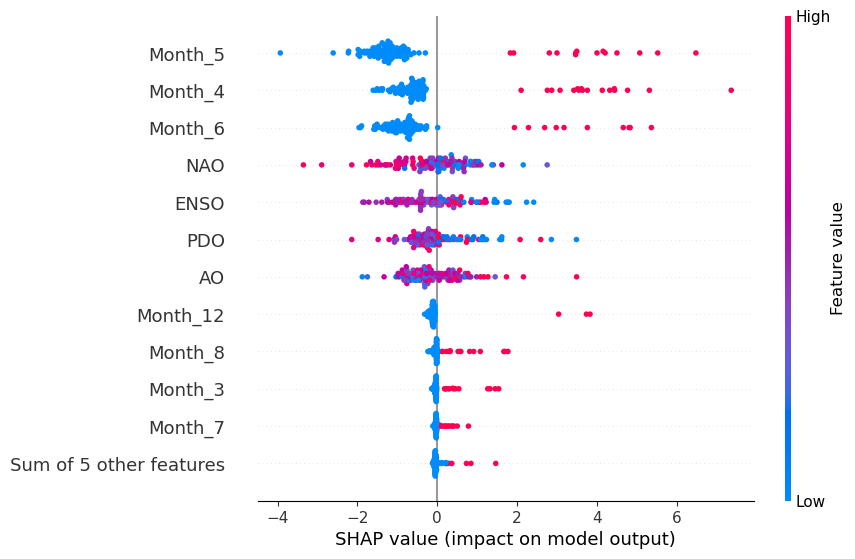

In [32]:
shap.plots.beeswarm(shap_values, max_display=12)

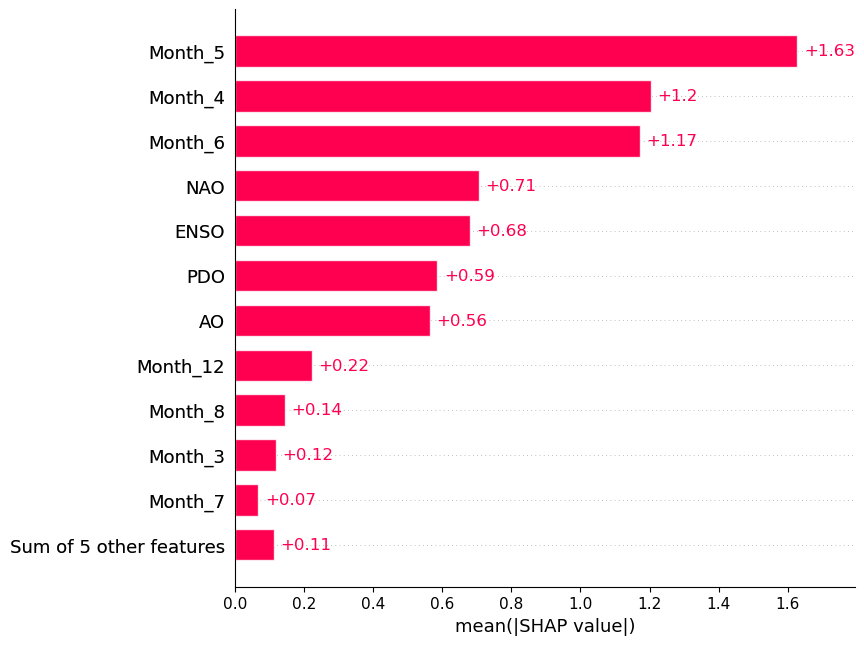

In [33]:
shap.plots.bar(shap_values, max_display=12)

7. Create a SHAP Feature Dependence for the ENSO index.

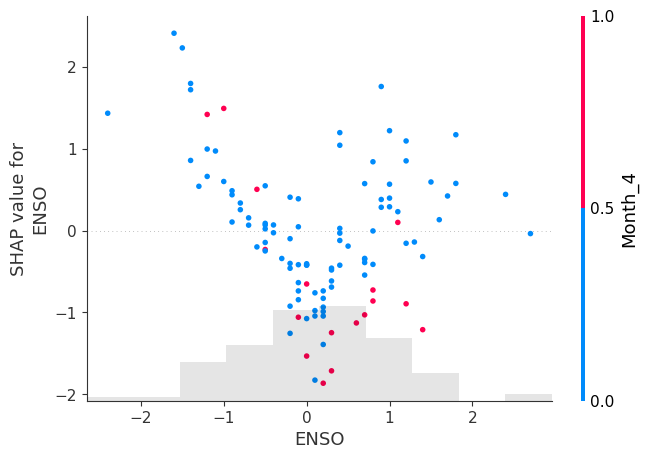

In [34]:
# ENSO dependence colored by strongest interaction automatically
shap.plots.scatter(shap_values[:, 'ENSO'], color=shap_values)

8. Any observations on the importance of the various features in your model from the XAI techniques you tried?

I generally observe that months 5, 4, and 6 (May, April, and June) are the features that are the primary drivers for predicting tornado count, so I guess this indicates high seasonality (aka tornado happen in the spring). The climate indices do not seem to be extremely influential in predicting tornado count, but NOA and ENSO are the top two. Based on the beeswarm plot,for NOA, there are more blue point on the positive side and red points on the negative side, indicating that lower NOA value increases predicted tornado count.

Based on the SHAP Feature Dependence plot for ENSO, the chart returned Month_4 (April) as the feature with the most interaction with ENSO. There are generally more red points (April) closer to where ENSO = 0, and blue points (not-April) have more varied values for ENSO. I take this to mean that ENSO does not have a lot of influence on tornado counts in the month of April, but may have a greater effect on other months of the year.

